In [177]:
# -- Library imports
import time
import pandas as pd
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt

In [151]:
# -- Checking if options are the same for both tickers
ticker = yf.Ticker("AAPL")
options = [method for method in dir(ticker) if not method.startswith('_')]
ticker2 = yf.Ticker("BTC-EUR")
options2 = [method for method in dir(ticker2) if not method.startswith('_')]
print(options == options2)
options

True


['actions',
 'analyst_price_targets',
 'balance_sheet',
 'balancesheet',
 'calendar',
 'capital_gains',
 'cash_flow',
 'cashflow',
 'dividends',
 'earnings',
 'earnings_dates',
 'earnings_estimate',
 'earnings_history',
 'eps_revisions',
 'eps_trend',
 'fast_info',
 'financials',
 'funds_data',
 'get_actions',
 'get_analyst_price_targets',
 'get_balance_sheet',
 'get_balancesheet',
 'get_calendar',
 'get_capital_gains',
 'get_cash_flow',
 'get_cashflow',
 'get_dividends',
 'get_earnings',
 'get_earnings_dates',
 'get_earnings_estimate',
 'get_earnings_history',
 'get_eps_revisions',
 'get_eps_trend',
 'get_fast_info',
 'get_financials',
 'get_funds_data',
 'get_growth_estimates',
 'get_history_metadata',
 'get_income_stmt',
 'get_incomestmt',
 'get_info',
 'get_insider_purchases',
 'get_insider_roster_holders',
 'get_insider_transactions',
 'get_institutional_holders',
 'get_isin',
 'get_major_holders',
 'get_mutualfund_holders',
 'get_news',
 'get_recommendations',
 'get_recommendatio

In [152]:
# -- Ticker options descriptions
options = [method for method in dir(ticker) if not method.startswith('_')]
dict_options = {
    # 💰 Datos Básicos e Históricos
    "info"                       : "Diccionario completo con métricas financieras y metadatos de la empresa.",
    "get_info"                   : "Función que obtiene 'info'.",
    "fast_info"                  : "Resumen rápido de métricas principales (carga más rápido que 'info').",
    "get_fast_info"              : "Función que obtiene 'fast_info'.",
    "history"                    : "Descarga precios históricos (Apertura, Máximo, Mínimo, Cierre, Volumen).",
    "history_metadata"           : "Metadatos sobre la última petición de datos históricos (zona horaria, rangos).",
    "get_history_metadata"       : "Función que obtiene 'history_metadata'.",
    "ticker"                     : "Devuelve el símbolo bursátil en formato texto (ej. 'AAPL').",
    "session"                    : "Muestra la sesión HTTP interna de la librería.",
    "live"                       : "Método para recibir precios en tiempo real (si está disponible).",
    "ws"                         : "Conexión WebSockets interna para datos en tiempo real.",
    "isin"                       : "Código ISIN (International Securities Identification Number) del activo.",
    "get_isin"                   : "Función que obtiene el ISIN.",

    # 📊 Estados Financieros (Anuales)
    "financials"                 : "Cuenta de resultados (Income Statement) anual.",
    "get_financials"             : "Función que obtiene 'financials'.",
    "income_stmt"                : "Alias moderno de 'financials' (Cuenta de resultados).",
    "incomestmt"                 : "Alias de 'income_stmt'.",
    "get_income_stmt"            : "Función que obtiene 'income_stmt'.",
    "get_incomestmt"             : "Función que obtiene 'incomestmt'.",
    "balance_sheet"              : "Balance general anual (Activos, Pasivos, Patrimonio).",
    "balancesheet"               : "Alias de 'balance_sheet'.",
    "get_balance_sheet"          : "Función que obtiene 'balance_sheet'.",
    "get_balancesheet"           : "Función que obtiene 'balancesheet'.",
    "cash_flow"                  : "Estado de flujos de efectivo anual.",
    "cashflow"                   : "Alias de 'cash_flow'.",
    "get_cash_flow"              : "Función que obtiene 'cash_flow'.",
    "get_cashflow"               : "Función que obtiene 'cashflow'.",
    "earnings"                   : "Historial de ingresos y ganancias.",
    "get_earnings"               : "Función que obtiene 'earnings'.",

    # ⏱️ Estados Financieros (Trimestrales y últimos 12 meses - TTM)
    "quarterly_financials"       : "Cuenta de resultados (Trimestral).",
    "quarterly_income_stmt"      : "Alias de cuenta de resultados (Trimestral).",
    "quarterly_incomestmt"       : "Alias de cuenta de resultados (Trimestral).",
    "quarterly_balance_sheet"    : "Balance general (Trimestral).",
    "quarterly_balancesheet"     : "Alias de balance general (Trimestral).",
    "quarterly_cash_flow"        : "Estado de flujos de efectivo (Trimestral).",
    "quarterly_cashflow"         : "Alias de estado de flujos de efectivo (Trimestral).",
    "quarterly_earnings"         : "Ganancias e ingresos (Trimestral).",
    "ttm_financials"             : "Cuenta de resultados (Trailing Twelve Months - últimos 12 meses).",
    "ttm_income_stmt"            : "Alias de cuenta de resultados TTM.",
    "ttm_incomestmt"             : "Alias de cuenta de resultados TTM.",
    "ttm_cash_flow"              : "Flujos de efectivo TTM.",
    "ttm_cashflow"               : "Alias de flujos de efectivo TTM.",

    # 💸 Acciones Corporativas
    "actions"                    : "Historial completo de pago de dividendos y splits.",
    "get_actions"                : "Función que obtiene 'actions'.",
    "dividends"                  : "Historial de dividendos pagados.",
    "get_dividends"              : "Función que obtiene 'dividends'.",
    "splits"                     : "Historial de desdoblamientos (splits) de la acción.",
    "get_splits"                 : "Función que obtiene 'splits'.",
    "capital_gains"              : "Distribución de ganancias de capital (principalmente ETFs/Fondos).",
    "get_capital_gains"          : "Función que obtiene 'capital_gains'.",
    "shares"                     : "Evolución histórica de la cantidad de acciones en circulación.",
    "get_shares"                 : "Función que obtiene 'shares'.",
    "get_shares_full"            : "Obtiene el historial más detallado posible de acciones en circulación.",

    # 👥 Accionistas e Insiders
    "major_holders"              : "Desglose de tipos de inversores (insiders vs instituciones).",
    "get_major_holders"          : "Función que obtiene 'major_holders'.",
    "institutional_holders"      : "Lista de las grandes instituciones que poseen acciones.",
    "get_institutional_holders"  : "Función que obtiene 'institutional_holders'.",
    "mutualfund_holders"         : "Lista de fondos mutuos que poseen estas acciones.",
    "get_mutualfund_holders"     : "Función que obtiene 'mutualfund_holders'.",
    "insider_roster_holders"     : "Lista de directivos (CEO, CFO...) y corporativos principales.",
    "get_insider_roster_holders" : "Función que obtiene 'insider_roster_holders'.",
    "insider_purchases"          : "Resumen de compras/ventas hechas por miembros internos.",
    "get_insider_purchases"      : "Función que obtiene 'insider_purchases'.",
    "insider_transactions"       : "Historial detallado de operaciones bursátiles de directivos.",
    "get_insider_transactions"   : "Función que obtiene 'insider_transactions'.",

    # 🎯 Predicciones, Analistas y Valoración
    "analyst_price_targets"      : "Precios objetivos (bajo, promedio, alto) de Wall Street.",
    "get_analyst_price_targets"  : "Función que obtiene 'analyst_price_targets'.",
    "recommendations"            : "Historial de recomendaciones de analistas (Buy, Sell, Hold).",
    "get_recommendations"        : "Función que obtiene 'recommendations'.",
    "recommendations_summary"    : "Resumen actual (cuántos recomiendan comprar/vender).",
    "get_recommendations_summary": "Función que obtiene 'recommendations_summary'.",
    "upgrades_downgrades"        : "Historial de mejoras o empeoramientos de calificación de analistas.",
    "get_upgrades_downgrades"    : "Función que obtiene 'upgrades_downgrades'.",
    "earnings_estimate"          : "Estimaciones futuras de beneficios por acción (EPS).",
    "get_earnings_estimate"      : "Función que obtiene 'earnings_estimate'.",
    "revenue_estimate"           : "Estimaciones futuras de ingresos totales.",
    "get_revenue_estimate"       : "Función que obtiene 'revenue_estimate'.",
    "growth_estimates"           : "Pronóstico de crecimiento futuro esperado.",
    "get_growth_estimates"       : "Función que obtiene 'growth_estimates'.",
    "eps_trend"                  : "Tendencia histórica de las estimaciones del EPS.",
    "get_eps_trend"              : "Función que obtiene 'eps_trend'.",
    "eps_revisions"              : "Revisiones al alza/baja que los analistas le hacen al EPS esperado.",
    "get_eps_revisions"          : "Función que obtiene 'eps_revisions'.",
    "earnings_history"           : "Historial de beneficios reales vs las expectativas (sorpresas).",
    "get_earnings_history"       : "Función que obtiene 'earnings_history'.",
    "valuation"                  : "Métricas de valoración (PER, PEG, P/B) de años pasados.",
    "get_valuation_measures"     : "Función que obtiene 'valuation'.",

    # 🗓️ Eventos y Noticias
    "calendar"                   : "Eventos programados próximos (ej. presentación de resultados).",
    "get_calendar"               : "Función que obtiene 'calendar'.",
    "earnings_dates"             : "Historial y proyecciones de las fechas de presentación de resultados.",
    "get_earnings_dates"         : "Función que obtiene 'earnings_dates'.",
    "news"                       : "Lista de artículos de noticias recientes relacionados a la empresa.",
    "get_news"                   : "Función que obtiene 'news'.",
    "sec_filings"                : "Enlaces a reportes oficiales presentados ante la SEC (10-K, 10-Q).",
    "get_sec_filings"            : "Función que obtiene 'sec_filings'.",

    # 🎰 Opciones (Derivados)
    "options"                    : "Tupla con todas las fechas de expiración disponibles de contratos de opciones.",
    "option_chain"               : "Libro de órdenes y volumen de contratos (Calls y Puts) dada una fecha.",

    # 🌲 Criterios ASG y Fondos
    "sustainability"             : "Puntuación de riesgo ESG (Ambiental, Social, Gobernanza).",
    "get_sustainability"         : "Función que obtiene 'sustainability'.",
    "funds_data"                 : "Información detallada exclusiva si el Ticker es un Fondo o ETF.",
    "get_funds_data"             : "Función que obtiene 'funds_data'."}

df_options = pd.DataFrame({"Option": options, "Description": [dict_options.get(op, "Variante no descrita") for op in options]})
df_options

,Option,Description
0,actions,Historial completo de pago de dividendos y spl...
1,analyst_price_targets,"Precios objetivos (bajo, promedio, alto) de Wa..."
2,balance_sheet,"Balance general anual (Activos, Pasivos, Patri..."
3,balancesheet,Alias de 'balance_sheet'.
4,calendar,Eventos programados próximos (ej. presentación...
...,...,...
96,ttm_income_stmt,Alias de cuenta de resultados TTM.
97,ttm_incomestmt,Alias de cuenta de resultados TTM.
98,upgrades_downgrades,Historial de mejoras o empeoramientos de calif...
99,valuation,"Métricas de valoración (PER, PEG, P/B) de años..."


In [153]:
dict_tickers = {
    "AAPL"   : "Apple",
    "IWDE.L" : "MSCI World EUR Hedged",
    "IUSE.L" : "S&P 500 EUR Hedged",
    "SGLN.L" : "Oro",
    "ISLN.L" : "Plata",
    "BTC-EUR": "Bitcoin",
    "^IBEX"  : "IBEX 35",
    "EXXT.DE": "NASDAQ 100 EUR Hedged"}

def load_message(tickers):
    print(f"\n--- 📡 Streaming: {datetime.now().strftime('%H:%M:%S')} ---")
    for active in tickers.items():
        try:
            ticker = yf.Ticker(active[0])
            info = ticker.fast_info
            price = info['last_price']
            currency = info['currency']
            message = {
                "ticker": active[1],
                "price": round(price, 2),
                "currency": currency,
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
            print(f"✅ {message['ticker']}: {message['price']} {message['currency']}")
        except Exception as e:
            print(f"⚠️ {active[1]}: No se pudo obtener el precio")

# try:#     
#         while True:
#         consultar_limpio(mis_activos)
#         time.sleep(5) # Consultamos cada 5 segundos
# except KeyboardInterrupt:
#     print("\nDeteniendo el flujo de datos...")
load_message(dict_tickers)


--- 📡 Streaming: 17:25:41 ---
✅ Apple: 272.32 USD
✅ MSCI World EUR Hedged: 111.43 EUR
✅ S&P 500 EUR Hedged: 146.53 EUR
✅ Oro: 6809.7 GBp
✅ Plata: 74.26 USD
✅ Bitcoin: 67366.92 EUR
✅ IBEX 35: 18015.9 EUR
✅ NASDAQ 100 EUR Hedged: 222.5 EUR


In [173]:
dict_tickers = {
    # "AAPL"   : "Apple",
    "IWDE.L" : "MSCI World EUR Hedged",
    "IUSE.L" : "S&P 500 EUR Hedged",
    "SGLN.L" : "Oro",
    "ISLN.L" : "Plata",
    "BTC-EUR": "Bitcoin",
    "^IBEX"  : "IBEX 35",
    "EXXT.DE": "NASDAQ 100 EUR Hedged"}
list_tickers_keys = [key for key in dict_tickers.keys()]
list_tickers_values = [value for value in dict_tickers.values()]

rows = []
for active in dict_tickers.items():
    ticker = yf.Ticker(active[0])
    rows.append(ticker.info)
df = pd.DataFrame(rows)
df['symbol'] = df['symbol'].map(dict_tickers)
df = df.set_index('symbol').reset_index().rename(columns={'symbol': 'Ticker'})

df.describe()
df

,Ticker,phone,companyOfficers,executiveTeam,maxAge,priceHint,previousClose,open,dayLow,dayHigh,...,volumeAllCurrencies,circulatingSupply,maxSupply,totalSupply,fullyDilutedValue,volume24HrMarketCapPercent,coinImageUrl,logoUrl,52WeekChange,displayName
0,MSCI World EUR Hedged,353 1 246 7000,[],[],86400,2,111.250,111.520,111.240,111.6600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S&P 500 EUR Hedged,353 1 246 7000,[],[],86400,2,145.980,146.270,146.030,146.7200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Oro,NaN,NaN,NaN,86400,2,6815.000,6842.000,6794.000,6849.9170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Plata,NaN,NaN,NaN,86400,2,73.280,74.770,73.755,74.8275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bitcoin,NaN,[],[],86400,2,65004.906,65004.906,64870.684,67560.7340,...,4.042809e+10,20019360.0,21000000.0,20019360.0,1.420570e+12,0.029894,https://s2.coinmarketcap.com/static/img/coins/...,https://s2.coinmarketcap.com/static/img/coins/...,NaN,NaN
5,IBEX 35,NaN,NaN,NaN,86400,2,18142.600,18193.100,17981.400,18222.5000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.357567,IBEX 35
6,NASDAQ 100 EUR Hedged,+33 (0) 01 70 91 85 50,[],[],86400,2,219.850,220.800,220.500,222.8000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [195]:
dict_descriptions = {
    "phone"                            : "Número de teléfono de contacto de la empresa.",
    "companyOfficers"                  : "Lista y datos de los directivos principales.",
    "executiveTeam"                    : "Información sobre el equipo ejecutivo o junta directiva.",
    "maxAge"                           : "Tiempo máximo (en seg) de validez de los datos.",
    "priceHint"                        : "Decimales a usar para mostrar el precio.",
    "previousClose"                    : "Precio al que cerró el activo en la sesión anterior.",
    "open"                             : "Precio al que abrió el activo en la sesión actual.",
    "dayLow"                           : "El precio más bajo alcanzado durante el día actual.",
    "dayHigh"                          : "El precio más alto alcanzado durante el día actual.",
    "regularMarketPreviousClose"       : "Cierre anterior en horario regular.",
    "regularMarketOpen"                : "Apertura en horario regular.",
    "regularMarketDayLow"              : "Mínimo del día en horario regular.",
    "regularMarketDayHigh"             : "Máximo del día en horario regular.",
    "trailingPE"                       : "Ratio PER calculado sobre los últimos 12 meses.",
    "volume"                           : "Cantidad total de activos negociados hoy.",
    "regularMarketVolume"              : "Volumen negociado en horario regular.",
    "averageVolume"                    : "Volumen medio de negociación diario.",
    "averageVolume10days"              : "Volumen medio de negociación (10 días).",
    "averageDailyVolume10Day"          : "Volumen medio de negociación (10 días).",
    "bid"                              : "Precio de compra (oferta máxima).",
    "ask"                              : "Precio de venta (demanda mínima).",
    "bidSize"                          : "Cantidad disponible al precio de compra.",
    "askSize"                          : "Cantidad disponible al precio de venta.",
    "yield"                            : "Rendimiento general del activo.",
    "totalAssets"                      : "Valor total de los activos gestionados.",
    "fiftyTwoWeekLow"                  : "Mínimo de las últimas 52 semanas.",
    "fiftyTwoWeekHigh"                 : "Máximo de las últimas 52 semanas.",
    "allTimeHigh"                      : "Máximo histórico.",
    "allTimeLow"                       : "Mínimo histórico.",
    "fiftyDayAverage"                  : "Media móvil de 50 días.",
    "twoHundredDayAverage"             : "Media móvil de 200 días.",
    "navPrice"                         : "Valor Liquidativo (NAV) del fondo.",
    "currency"                         : "Divisa del precio del activo.",
    "tradeable"                        : "Indica si se puede operar el activo.",
    "ytdReturn"                        : "Retorno acumulado del año actual (YTD).",
    "beta3Year"                        : "Volatilidad del activo a 3 años (Beta).",
    "fundFamily"                       : "Entidad gestora del fondo.",
    "fundInceptionDate"                : "Fecha de lanzamiento del fondo.",
    "legalType"                        : "Estructura legal de la entidad.",
    "threeYearAverageReturn"           : "Rentabilidad media a 3 años.",
    "fiveYearAverageReturn"            : "Rentabilidad media a 5 años.",
    "quoteType"                        : "Tipo de cotización (EQUITY, ETF, CRYPTO...).",
    "symbol"                           : "Símbolo bursátil (Ticker).",
    "language"                         : "Idioma de los metadatos.",
    "region"                           : "País o región del activo.",
    "typeDisp"                         : "Nombre legible del tipo de activo.",
    "quoteSourceName"                  : "Proveedor de datos financieros.",
    "triggerable"                      : "Admite alertas de precio.",
    "customPriceAlertConfidence"       : "Fiabilidad para alertas personalizadas.",
    "marketState"                      : "Estado actual del mercado (abierto/cerrado).",
    "hasPrePostMarketData"             : "Tiene datos pre/post mercado.",
    "firstTradeDateMilliseconds"       : "Fecha de la primera cotización registrada.",
    "regularMarketChange"              : "Cambio absoluto frente al cierre.",
    "regularMarketDayRange"            : "Rango mínimo-máximo del día.",
    "fullExchangeName"                 : "Nombre completo de la bolsa.",
    "averageDailyVolume3Month"         : "Volumen medio a 3 meses.",
    "fiftyTwoWeekLowChange"            : "Diferencia con el mínimo de 52 semanas.",
    "fiftyTwoWeekLowChangePercent"     : "Diferencia % con el mínimo de 52 semanas.",
    "fiftyTwoWeekRange"                : "Rango de 52 semanas.",
    "fiftyTwoWeekHighChange"           : "Diferencia con el máximo de 52 semanas.",
    "fiftyTwoWeekHighChangePercent"    : "Diferencia % con el máximo de 52 semanas.",
    "fiftyTwoWeekChangePercent"        : "Cambio % total en 52 semanas.",
    "dividendYield"                    : "Rentabilidad por dividendo anualizada.",
    "trailingThreeMonthReturns"        : "Rentabilidad a 3 meses.",
    "trailingThreeMonthNavReturns"     : "Rentabilidad NAV a 3 meses.",
    "netAssets"                        : "Activos netos bajo gestión.",
    "epsTrailingTwelveMonths"          : "Beneficio por acción (12 meses).",
    "fiftyDayAverageChange"            : "Diferencia con media de 50 días.",
    "fiftyDayAverageChangePercent"     : "Diferencia % con media de 50 días.",
    "twoHundredDayAverageChange"       : "Diferencia con media de 200 días.",
    "twoHundredDayAverageChangePercent": "Diferencia % con media de 200 días.",
    "netExpenseRatio"                  : "Ratio de gastos del fondo.",
    "corporateActions"                 : "Historial de acciones corporativas.",
    "regularMarketTime"                : "Timestamp de la última cotización.",
    "exchange"                         : "Símbolo corto de la bolsa.",
    "messageBoardId"                   : "ID para foros de discusión.",
    "exchangeTimezoneName"             : "Zona horaria oficial.",
    "exchangeTimezoneShortName"        : "Abreviatura de zona horaria.",
    "gmtOffSetMilliseconds"            : "Diferencia en ms respecto a GMT.",
    "market"                           : "Identificador interno del mercado.",
    "esgPopulated"                     : "Tiene datos ASG disponibles.",
    "longName"                         : "Nombre legal completo.",
    "sourceInterval"                   : "Intervalo de actualización de la fuente.",
    "exchangeDataDelayedBy"            : "Minutos de retraso de datos.",
    "cryptoTradeable"                  : "Criptomoneda negociable.",
    "shortName"                        : "Nombre comercial corto.",
    "regularMarketChangePercent"       : "Cambio % en mercado regular.",
    "regularMarketPrice"               : "Precio actual en mercado regular.",
    "trailingPegRatio"                 : "Ratio PEG histórico.",
    "website"                          : "Web oficial.",
    "blockNumber"                      : "Número de bloque en blockchain.",
    "blockReward"                      : "Recompensa por bloque minado.",
    "blockRewardReduction"             : "Datos sobre el Halving.",
    "netHashesPerSecond"               : "Tasa de Hash de la red.",
    "name"                             : "Nombre general o abreviado.",
    "startDate"                        : "Fecha de inicio/lanzamiento.",
    "description"                      : "Descripción general de la empresa/fondo.",
    "whitepaper"                       : "Documento técnico de la cripto.",
    "marketCap"                        : "Capitalización de mercado.",
    "fromCurrency"                     : "Moneda base.",
    "toCurrency"                       : "Moneda de cotización.",
    "lastMarket"                       : "Último mercado en el que operó.",
    "coinMarketCapLink"                : "Enlace a CoinMarketCap.",
    "volume24Hr"                       : "Volumen operado en 24h.",
    "volumeAllCurrencies"              : "Volumen 24h en todas las divisas.",
    "circulatingSupply"                : "Monedas en circulación.",
    "maxSupply"                        : "Límite máximo de monedas.",
    "totalSupply"                      : "Monedas creadas hasta ahora.",
    "fullyDilutedValue"                : "Valoración totalmente diluida.",
    "volume24HrMarketCapPercent"       : "Ratio volumen 24h / Market Cap.",
    "coinImageUrl"                     : "URL de imagen de la criptomoneda.",
    "logoUrl"                          : "URL del logotipo.",
    "52WeekChange"                     : "Cambio absoluto en 52 semanas.",
    "displayName"                      : "Nombre para interfaz de usuario."}

descriptions = [dict_descriptions.get(col, "Sin descripción disponible.") for col in df.columns]
df_descriptions = pd.DataFrame({"Column": df.columns, "Data Type": df.dtypes.values, "Description": descriptions})
# df_descriptions[df_descriptions["Description"]=="Sin descripción disponible."]["Column"].tolist()
df_descriptions

,Column,Data Type,Description
0,Ticker,str,Sin descripción disponible.
1,phone,str,Número de teléfono de contacto de la empresa.
2,companyOfficers,object,Lista y datos de los directivos principales.
3,executiveTeam,object,Información sobre el equipo ejecutivo o junta ...
4,maxAge,int64,Tiempo máximo (en seg) de validez de los datos.
...,...,...,...
109,volume24HrMarketCapPercent,float64,Ratio volumen 24h / Market Cap.
110,coinImageUrl,str,URL de imagen de la criptomoneda.
111,logoUrl,str,URL del logotipo.
112,52WeekChange,float64,Cambio absoluto en 52 semanas.


In [ ]:
# historial.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='str')

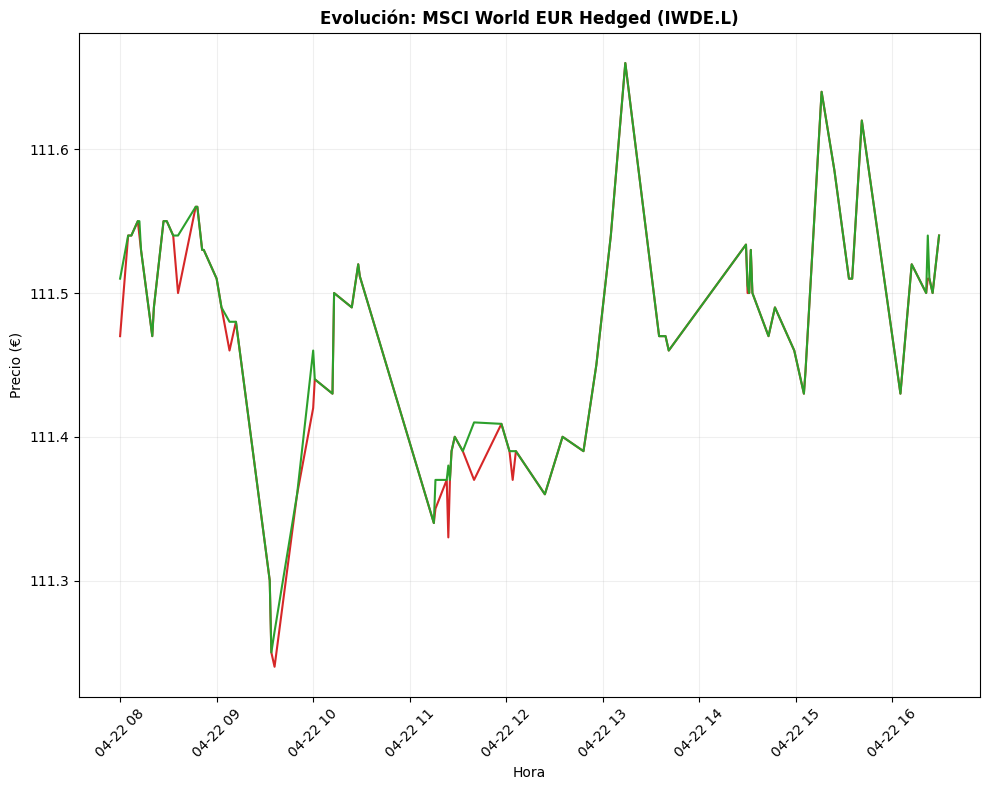

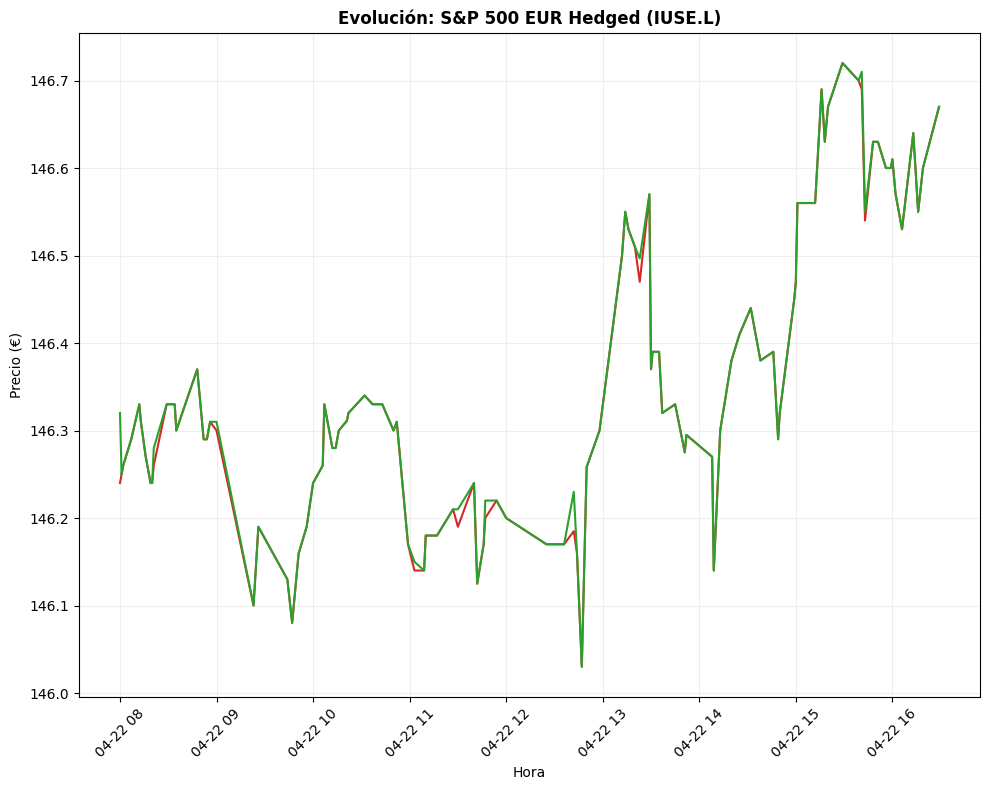

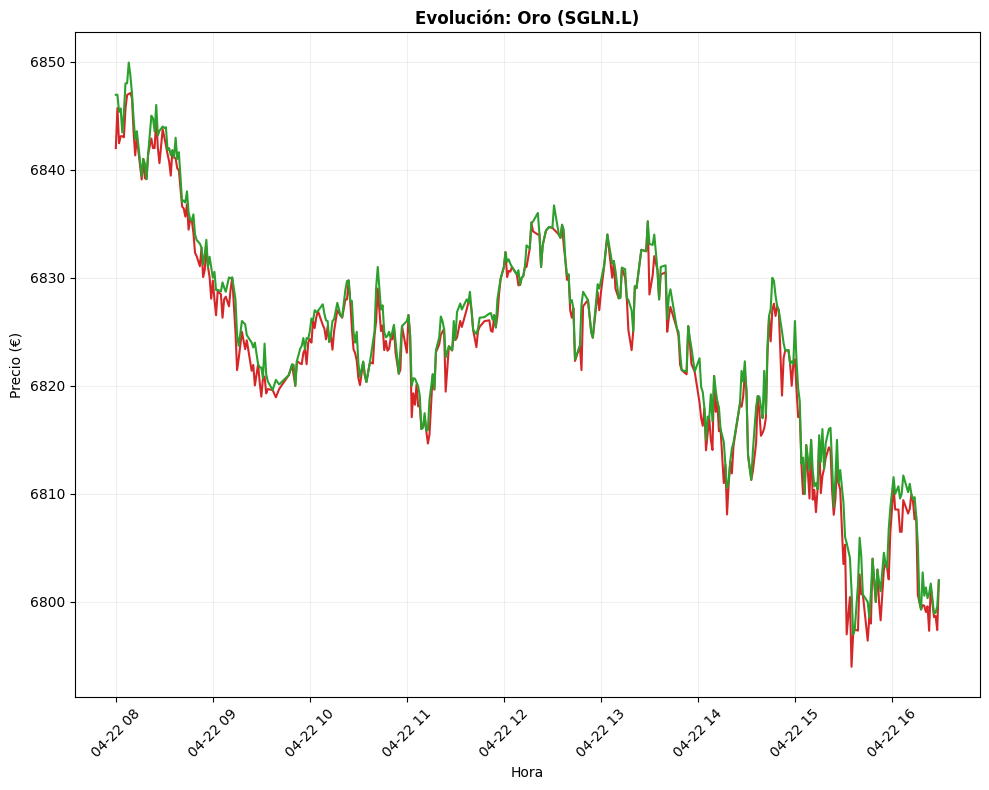

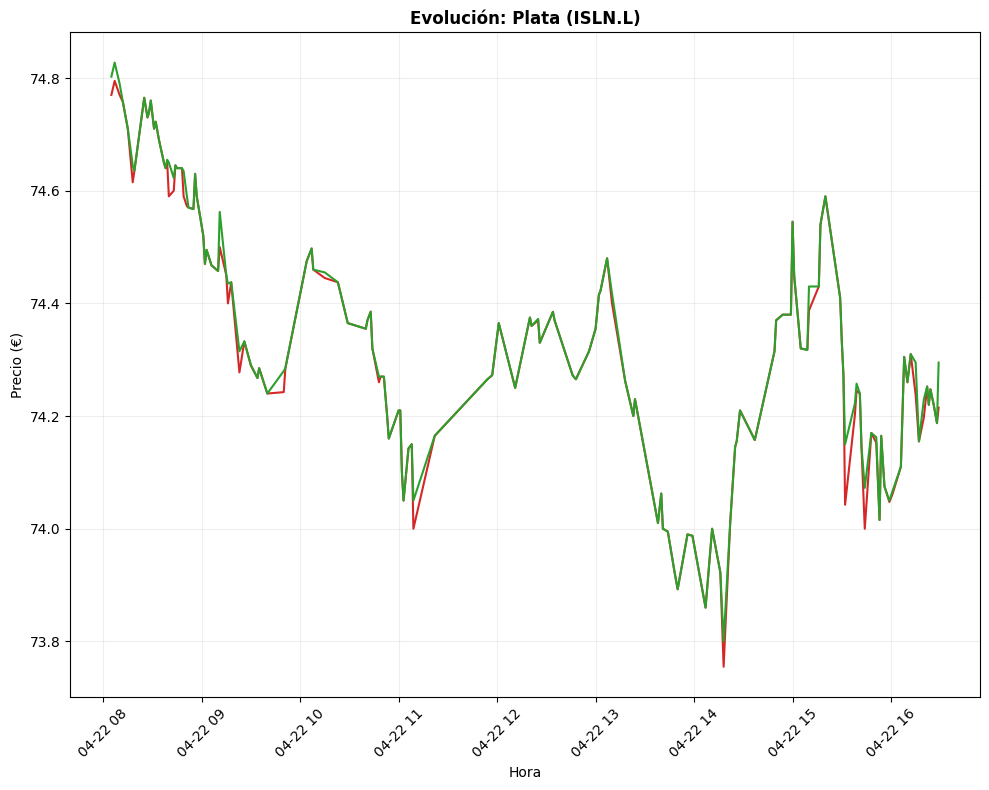

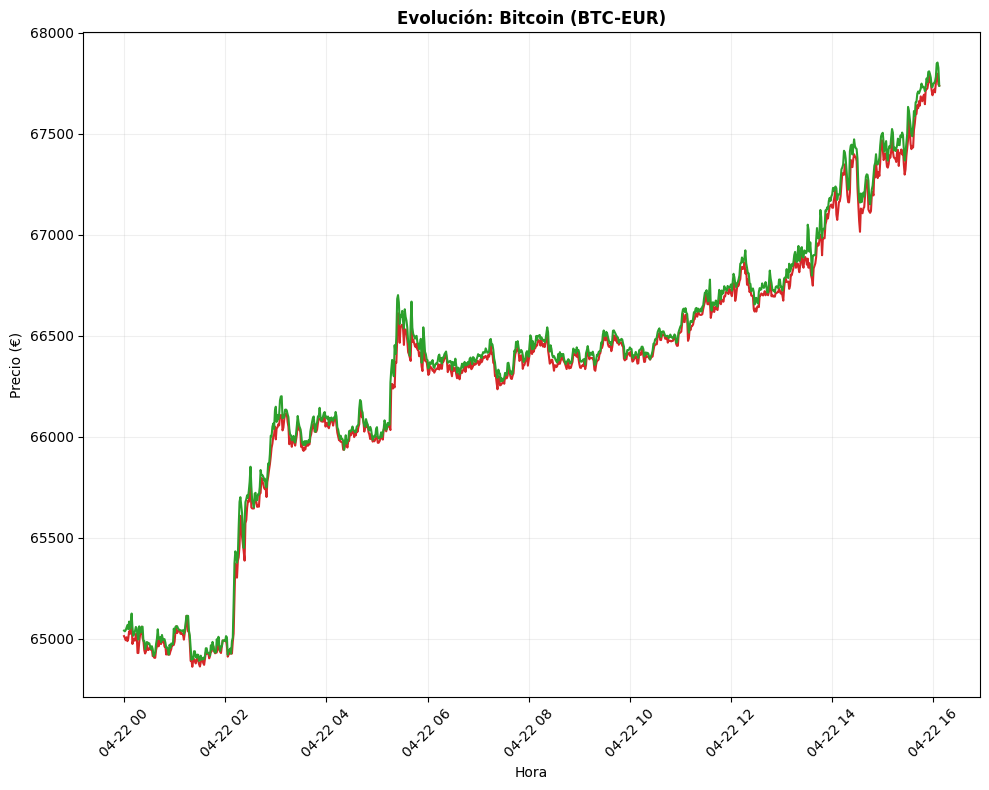

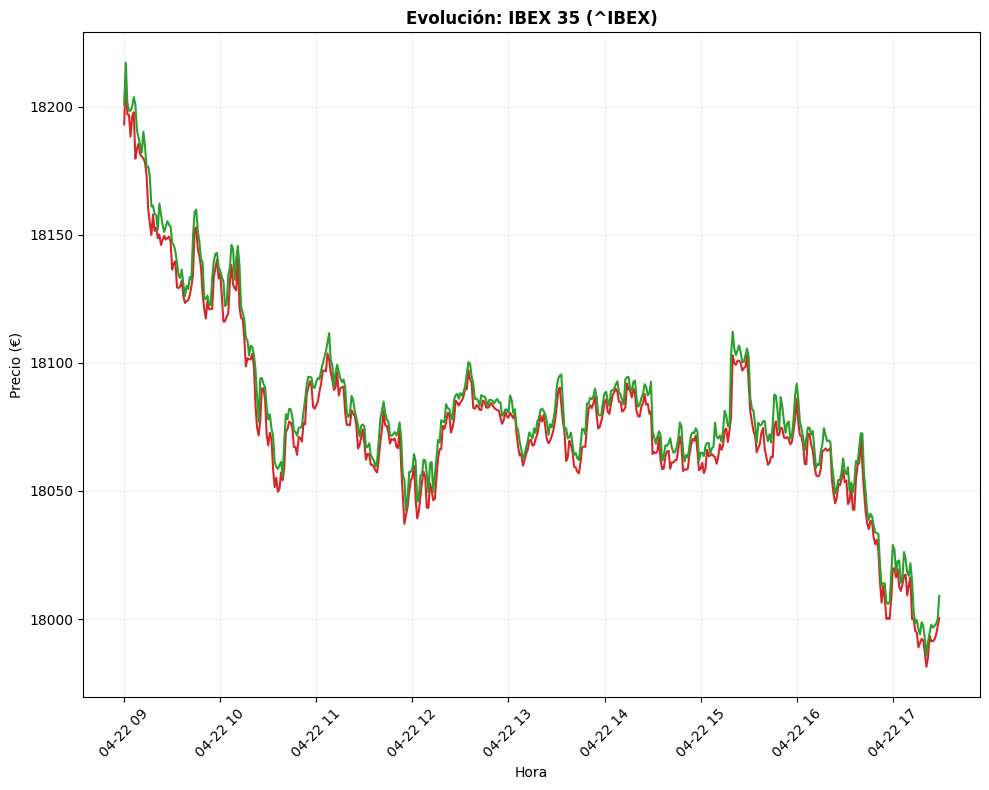

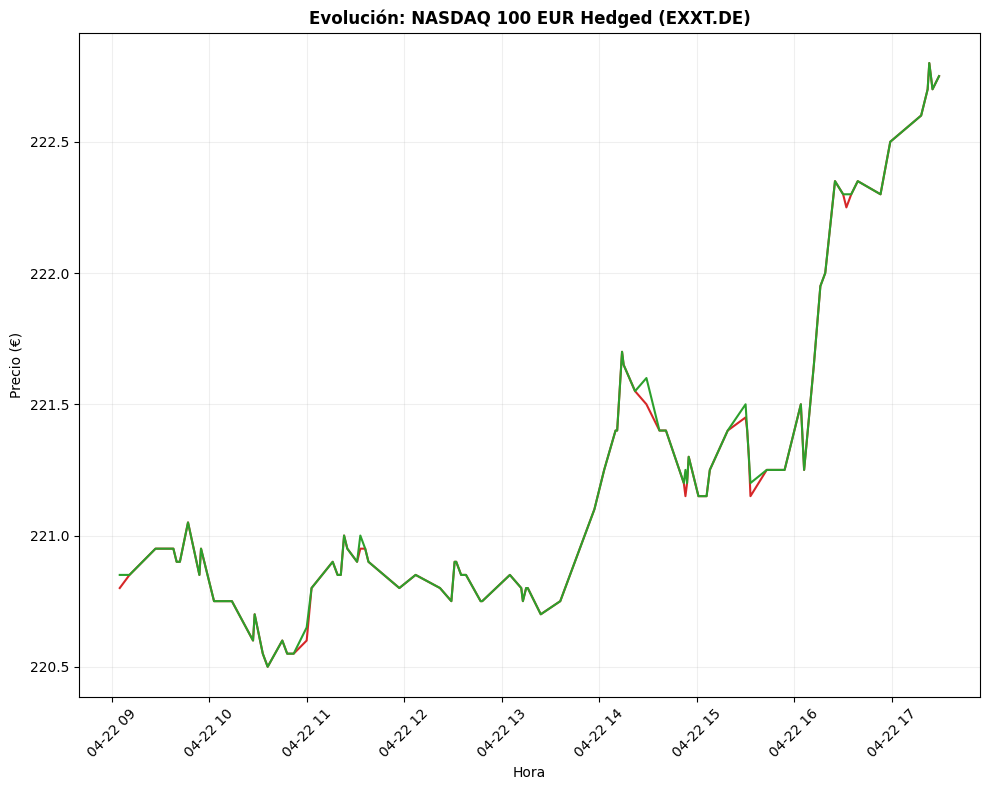

In [207]:
for i in list_tickers_keys:
    plt.figure(figsize=(10, 8)) 
    ticker = yf.Ticker(i)
    historial = ticker.history(period="1d", interval="1m")
    if not historial.empty:
        plt.plot(historial.index, historial['Low'], color='tab:red', linewidth=1.5)
        plt.plot(historial.index, historial['High'], color='tab:green', linewidth=1.5)
        nombre = dict_tickers.get(i, i)
        plt.title(f"Evolución: {nombre} ({i})", fontsize=12, fontweight='bold')
        plt.xlabel("Hora")
        plt.ylabel("Precio (€)")
        plt.grid(True, alpha=0.2)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos para {i}")

In [ ]:
# -- DataFrames
print([v for v in dir() if v.startswith('df')])

['df', 'df_descriptions', 'df_options']
